#### __`Importing Libraries, Setting Display Options`__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import percentileofscore

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))     # To view numerical values in dataframe columns uniformly
pd.set_option('display.max_columns', None)                              # To view all columns in .describe() 

#### __`Data Loading`__

In [3]:
readDF = pd.read_csv('old_population.csv')

In [4]:
df = readDF.copy()
df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,health_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,< 10L,6,Bronze,9053,0.24
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,< 10L,6,Bronze,16339,0.24
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,Silver,18164,0.24
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,Gold,20303,0.00
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Bronze,15610,0.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29817,60,Female,Northwest,Married,3,Normal,No Smoking,Self-Employed,25L - 40L,26,Gold,26370,0.24
29818,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,10L - 25L,16,Gold,29496,0.44
29819,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,< 10L,4,Bronze,10957,0.00
29820,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Gold,27076,0.20


#### __`Train-Test Split`__

In [5]:
X, y = df.drop(columns=['annual_premium_amount']), df['annual_premium_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### __`Data Pre-Processing Pipeline`__

In [10]:
num_features = ['age', 'number_of_dependants', 'income_lakhs', 'health_risk_score']
cat_features = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'insurance_plan']

nominal_features = ['gender', 'region', 'marital_status', 'employment_status']
ordinal_features = ['bmi_category', 'smoking_status', 'insurance_plan']

ordinal_categories = [
    ['Underweight', 'Normal', 'Overweight', 'Obesity'],
    ['No Smoking', 'Occasional', 'Regular'],
    ['Bronze', 'Silver', 'Gold']
]

preprocessor = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(drop='first'), nominal_features),
    ('numerical', StandardScaler(), num_features),
    ('ordinal', Pipeline(steps=[
        ('encode', OrdinalEncoder(categories=ordinal_categories)),
        ('scale', StandardScaler())]), ordinal_features)   
    ],
    remainder='drop',
    verbose_feature_names_out=False)

#### __`Model Training & Evaluation`__

In [11]:
def evaluate_model(model_name, X_train, X_test, y_train, y_test):
    
    # Train set Evaluation
    y_pred_train = model_name.predict(X_train)

    print('PERFORMANCE WITH TRAIN SET\n---------------------------')
    print(f"MAE        :  {mean_absolute_error(y_train, y_pred_train):,.2f}")
    print(f"MSE        :  {mean_squared_error(y_train, y_pred_train):,.2f}")
    print(f"RMSE       :  {np.sqrt(mean_squared_error(y_train, y_pred_train)):,.2f}")
    print(f"R2 Score   :  {r2_score(y_train, y_pred_train):.4f}")

    # Test set Evaluation
    y_pred_test = model_name.predict(X_test)

    print('\n\nPERFORMANCE WITH TEST SET\n---------------------------')
    print(f"MAE        :  {mean_absolute_error(y_test, y_pred_test):,.2f}")
    print(f"MSE        :  {mean_squared_error(y_test, y_pred_test):,.2f}")
    print(f"RMSE       :  {np.sqrt(mean_squared_error(y_test, y_pred_test)):,.2f}")
    print(f"R2 Score   :  {r2_score(y_test, y_pred_test):.4f}")

In [12]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb_regressor', XGBRegressor())
])

model.fit(X_train, y_train)
evaluate_model(model, X_train, X_test, y_train, y_test)

PERFORMANCE WITH TRAIN SET
---------------------------
MAE        :  213.78
MSE        :  64,946.38
RMSE       :  254.85
R2 Score   :  0.9986


PERFORMANCE WITH TEST SET
---------------------------
MAE        :  262.75
MSE        :  97,325.27
RMSE       :  311.97
R2 Score   :  0.9980


In [14]:
print('FEATURE IMPORTANCE : \n------------------------------------------')
print(pd.Series(model.named_steps['xgb_regressor'].feature_importances_, index=model.named_steps['preprocessor'].get_feature_names_out()).sort_values(ascending=False))

FEATURE IMPORTANCE : 
------------------------------------------
insurance_plan                    0.91
bmi_category                      0.03
health_risk_score                 0.02
smoking_status                    0.02
age                               0.02
number_of_dependants              0.00
income_lakhs                      0.00
marital_status_Unmarried          0.00
region_Northwest                  0.00
region_Southwest                  0.00
employment_status_Self-Employed   0.00
region_Southeast                  0.00
employment_status_Salaried        0.00
gender_Male                       0.00
dtype: float32


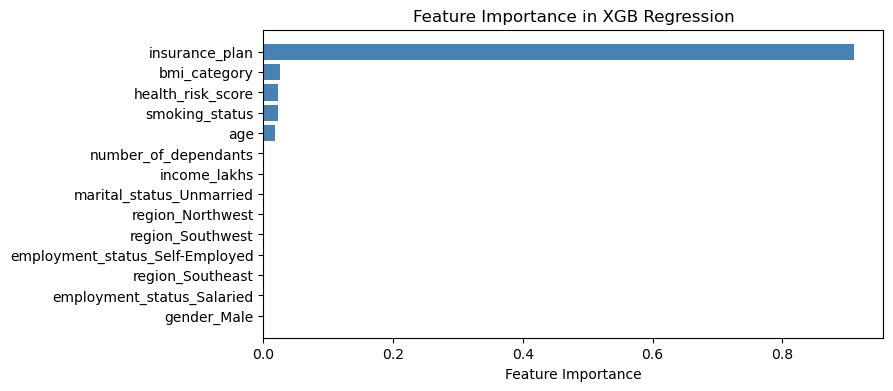

In [15]:
feature_importance_df = pd.DataFrame(
    model.named_steps['xgb_regressor'].feature_importances_,
    index=model.named_steps['preprocessor'].get_feature_names_out(),
    columns=['feature_importance']
    ).sort_values(by='feature_importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(feature_importance_df.index, feature_importance_df['feature_importance'], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance in XGB Regression')
plt.gca().invert_yaxis()
plt.show()

#### __`Error Analysis`__

In [16]:
y_pred = model.predict(X_test)

residuals = y_pred - y_test
residual_pct = (residuals/y_test)*100

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residual_pct
})

results_df = results_df.sort_values(by='diff_pct')
results_df

,actual,predicted,diff,diff_pct
469,8449,7829.70,-619.30,-7.33
14985,7596,7064.21,-531.79,-7.00
9632,33494,31376.76,-2117.24,-6.32
28525,8627,8084.00,-543.00,-6.29
27385,17064,16022.58,-1041.42,-6.10
...,...,...,...,...
6119,6538,7102.33,564.33,8.63
8194,6635,7249.55,614.55,9.26
17759,6569,7193.27,624.27,9.50
15365,6625,7283.41,658.41,9.94


<Axes: xlabel='diff_pct', ylabel='Count'>

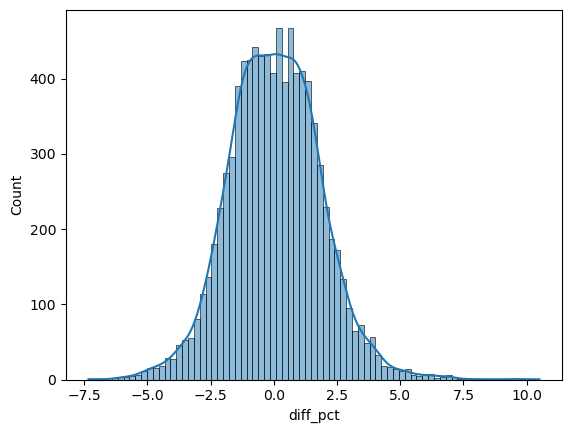

In [17]:
sns.histplot(results_df['diff_pct'], kde=True)

In [18]:
ERROR_THRESHOLD = 10

In [19]:
extreme_results_df = results_df[np.abs(results_df['diff_pct'])>ERROR_THRESHOLD]
extreme_results_df

,actual,predicted,diff,diff_pct
8248,6548,7235.64,687.64,10.50


In [21]:
print('Percent of Predictions with Extreme Errors : ', (extreme_results_df.shape[0]/results_df.shape[0])*100, '%')

Percent of Predictions with Extreme Errors :  0.011176930814798256 %


#### __`Exporting the Trained Model`__

In [22]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'region',
                                                   'marital_status',
                                                   'employment_status']),
                                                 ('numerical', StandardScaler(),
                                                  ['age',
                                                   'number_of_dependants',
                                                   'income_lakhs',
                                                   'health_risk_score']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('encode',
                                                                   OrdinalEncoder(categories=[['Underweight',
                                                                                               'Normal',
                                                                                               'Ove...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [25]:
import joblib

joblib.dump(model, './artifacts/old_population_model.joblib')

['./artifacts/old_population_model.joblib']